# Master Thesis — EDA + Methodology Test (Tagvenue)

**Topic:** Linguistic Drivers of Enquiry Conversion  
**Goal of this notebook:**  
1) Validate and explore the dataset (EDA)  
2) Run an end-to-end methodology test: baseline vs text vs combined models  
3) Produce reproducible outputs you can reference in the thesis

> Notes:
> - This notebook focuses on *prediction / signals*, not causal claims.
> - We exclude potential post-outcome variables (e.g., reviews/scores) from modeling to reduce leakage risk.


In [1]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
# --- 0) Setup ---
from pathlib import Path
from datetime import datetime, timezone
import re
import ast

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Single source of truth for local data folder
DATA_PATH = Path("/Users/trungnguyenvan/Documents/SGH/Thesis")

# Change filename if needed
DATA_FILE = DATA_PATH / "Marketplace_Data.csv"


In [3]:
# --- 1) Load data ---
df_raw = pd.read_csv(DATA_FILE)
print("Loaded:", DATA_FILE.name)
print("Shape:", df_raw.shape)

# Quick peek
df_raw.head(3)


Loaded: Marketplace_Data.csv
Shape: (73448, 24)


,venue_id,venue_name,room_id,room_name,venue_description,room_description,city,country,venue_types,venue_part,min_attendees_per_event,minimum_booking_hours,selected_for_online_payments,pricing_type,space_venue_type_label,room_min_price,room_max_price,pricing_methods,successful_enquiry_count,enquiry_count,number_of_verified_reviews,total_score,average_score,room_created_at
0,18984,Bond Collective East Austin,39786,Bouldin,Our first location in Texas is housed within t...,This completely private meeting room seats up ...,Austin,US,"[""meeting-centre"",""coworking-space""]",NaN,NaN,2.000,0,simplified,NaN,5000,5000,[hire fee],0,0,NaN,NaN,NaN,2022-07-27 14:28:36 UTC
1,18982,Charlie's,39785,Charlie’s,Charlie’s by the Charlie Borrow workshop. \n\n...,NaN,London,GB,"[""pub-bar""]",NaN,NaN,NaN,0,custom,NaN,15000,15000,[hire fee minimum spend],0,6,NaN,NaN,NaN,2022-07-27 14:22:04 UTC
2,21037,Abel's on the Lake,43883,Banqueting Hall,Abel’s on the Lake is the prime spot to come e...,It's time to plan your big event with Abel's o...,Austin,US,"[""restaurant""]",NaN,NaN,NaN,0,custom,NaN,2000,2000,[per person],0,2,NaN,NaN,NaN,2022-10-17 10:04:39 UTC


## 1. Column audit & schema check

We verify the schema and define a *column map* so the rest of the notebook is robust to naming differences.


In [4]:
df_raw.columns.tolist()

['venue_id',
 'venue_name',
 'room_id',
 'room_name',
 'venue_description',
 'room_description',
 'city',
 'country',
 'venue_types',
 'venue_part',
 'min_attendees_per_event',
 'minimum_booking_hours',
 'selected_for_online_payments',
 'pricing_type',
 'space_venue_type_label',
 'room_min_price',
 'room_max_price',
 'pricing_methods',
 'successful_enquiry_count',
 'enquiry_count',
 'number_of_verified_reviews',
 'total_score',
 'average_score',
 'room_created_at']

In [5]:
# --- Column map (adjust here if names change) ---
COL = {
    "venue_id": "venue_id",
    "venue_name": "venue_name",
    "room_id": "room_id",
    "room_name": "room_name",
    "venue_description": "venue_description",
    "room_description": "room_description",
    "city": "city",
    "country": "country",
    "venue_types": "venue_types",
    "venue_part": "venue_part",
    "min_attendees": "min_attendees_per_event",
    "min_hours": "minimum_booking_hours",
    "online_pay": "selected_for_online_payments",
    "pricing_type": "pricing_type",
    "space_type": "space_venue_type_label",
    "min_price": "room_min_price",
    "max_price": "room_max_price",
    "pricing_methods": "pricing_methods",
    "success_cnt": "successful_enquiry_count",
    "enquiry_cnt": "enquiry_count",
    "created_at": "room_created_at",
    # potential leakage / post-outcome signals (keep for EDA only)
    "reviews_cnt": "number_of_verified_reviews",
    "total_score": "total_score",
    "avg_score": "average_score",
}

missing_required = [v for k,v in COL.items() if k in ["venue_id","room_id","venue_description","room_description","success_cnt","enquiry_cnt","created_at"] and v not in df_raw.columns]
print("Missing required columns:", missing_required)


Missing required columns: []


## 2. Freeze thesis-relevant working dataset

We keep only the variables needed for EDA + modeling.  
For modeling, we will **exclude** review/score variables to reduce leakage risk.


In [6]:
KEEP_COLS = [
    COL["venue_id"], COL["venue_name"],
    COL["room_id"], COL["room_name"],
    COL["venue_description"], COL["room_description"],
    COL["city"], COL["country"],
    COL["venue_types"], COL["venue_part"],
    COL["min_attendees"], COL["min_hours"],
    COL["online_pay"], COL["pricing_type"], COL["space_type"],
    COL["min_price"], COL["max_price"],
    COL["pricing_methods"],
    COL["success_cnt"], COL["enquiry_cnt"],
    COL["created_at"],
    # EDA-only (potential leakage)
    COL["reviews_cnt"], COL["total_score"], COL["avg_score"],
]

KEEP_COLS = [c for c in KEEP_COLS if c in df_raw.columns]
df = df_raw[KEEP_COLS].copy()
print("Working df shape:", df.shape)
df.head(3)


Working df shape: (73448, 24)


,venue_id,venue_name,room_id,room_name,venue_description,room_description,city,country,venue_types,venue_part,min_attendees_per_event,minimum_booking_hours,selected_for_online_payments,pricing_type,space_venue_type_label,room_min_price,room_max_price,pricing_methods,successful_enquiry_count,enquiry_count,room_created_at,number_of_verified_reviews,total_score,average_score
0,18984,Bond Collective East Austin,39786,Bouldin,Our first location in Texas is housed within t...,This completely private meeting room seats up ...,Austin,US,"[""meeting-centre"",""coworking-space""]",NaN,NaN,2.000,0,simplified,NaN,5000,5000,[hire fee],0,0,2022-07-27 14:28:36 UTC,NaN,NaN,NaN
1,18982,Charlie's,39785,Charlie’s,Charlie’s by the Charlie Borrow workshop. \n\n...,NaN,London,GB,"[""pub-bar""]",NaN,NaN,NaN,0,custom,NaN,15000,15000,[hire fee minimum spend],0,6,2022-07-27 14:22:04 UTC,NaN,NaN,NaN
2,21037,Abel's on the Lake,43883,Banqueting Hall,Abel’s on the Lake is the prime spot to come e...,It's time to plan your big event with Abel's o...,Austin,US,"[""restaurant""]",NaN,NaN,NaN,0,custom,NaN,2000,2000,[per person],0,2,2022-10-17 10:04:39 UTC,NaN,NaN,NaN


## 3. Parse types & create core derived fields

- Parse dates and numeric fields  
- Create exposure (`age_days`)  
- Create targets aligned with Topic 1  
- Create unified cleaned text field


In [7]:
# --- Parse date ---
df[COL["created_at"]] = pd.to_datetime(df[COL["created_at"]], errors="coerce", utc=True)
print("room_created_at missing (%):", round(df[COL["created_at"]].isna().mean()*100, 2))
print("room_created_at range:", df[COL["created_at"]].min(), "→", df[COL["created_at"]].max())

# --- Parse counts ---
for c in [COL["enquiry_cnt"], COL["success_cnt"]]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

# --- Parse numeric controls ---
for c in [COL["min_price"], COL["max_price"], COL["min_attendees"], COL["min_hours"], COL["reviews_cnt"], COL["total_score"], COL["avg_score"]]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Exposure: age in days (use export time as-of-date) ---
AS_OF_DATE = pd.Timestamp(datetime.now(timezone.utc))
df["age_days"] = (AS_OF_DATE - df[COL["created_at"]]).dt.days
df["created_year"] = df[COL["created_at"]].dt.year

print(df["age_days"].describe(percentiles=[.5,.75,.9,.95,.99]))

# --- Targets ---
df["has_enquiry"] = (df[COL["enquiry_cnt"]] > 0).astype(int)
df["has_success"] = (df[COL["success_cnt"]] > 0).astype(int)

# Conversion rate (defined only when enquiry_count > 0)
df["conversion_rate"] = np.where(
    df[COL["enquiry_cnt"]] > 0,
    df[COL["success_cnt"]] / df[COL["enquiry_cnt"]],
    np.nan
)

print("has_enquiry share:", df["has_enquiry"].mean().round(4))
print("has_success share:", df["has_success"].mean().round(4))

# --- Text: combine venue + room description ---
df["full_description"] = (
    df[COL["venue_description"]].fillna("").astype(str) + " " +
    df[COL["room_description"]].fillna("").astype(str)
).str.strip()

def clean_text_basic(t: str) -> str:
    t = str(t).lower()
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["text_clean"] = df["full_description"].apply(clean_text_basic)
df["text_word_count"] = df["text_clean"].str.split().apply(len)

print("Empty text rows (%):", round((df["text_word_count"] == 0).mean()*100, 2))
print(df["text_word_count"].describe(percentiles=[.5,.75,.9,.95,.99]))


room_created_at missing (%): 0.04
room_created_at range: 2015-08-21 12:23:11+00:00 → 2025-12-10 17:39:20+00:00
count   73,420.000
mean     1,283.267
std        847.830
min        100.000
50%      1,255.000
75%      1,639.000
90%      2,545.000
95%      3,066.000
99%      3,640.000
max      3,864.000
Name: age_days, dtype: float64
has_enquiry share: 0.7914
has_success share: 0.237
Empty text rows (%): 0.0
count   73,448.000
mean       186.499
std         85.728
min          1.000
50%        163.000
75%        226.000
90%        303.000
95%        356.000
99%        481.000
max        740.000
Name: text_word_count, dtype: float64


## 4. EDA — Integrity, Missingness, Outcomes, Text

This section produces tables you can reference in the thesis:
- duplicates and unit-of-analysis checks  
- missingness table  
- target distributions and zero-inflation  
- basic text statistics  


# 4.1 Integrity checks

In [8]:
print("Duplicate room_id rows:", df.duplicated(subset=[COL["room_id"]]).sum())
print("Unique venues:", df[COL["venue_id"]].nunique())
print("Unique rooms:", df[COL["room_id"]].nunique())
print("Rooms per venue summary:")
print(df.groupby(COL["venue_id"])[COL["room_id"]].nunique().describe(percentiles=[.5,.75,.9,.95,.99]))

Duplicate room_id rows: 23664
Unique venues: 27132
Unique rooms: 49784
Rooms per venue summary:
count   27,132.000
mean         1.835
std          1.553
min          1.000
50%          1.000
75%          2.000
90%          4.000
95%          5.000
99%          8.000
max         30.000
Name: room_id, dtype: float64


# 4.2 Missingness

In [9]:
missing_pct = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_tbl = missing_pct.reset_index()
missing_tbl.columns = ["column", "missing_pct"]
missing_tbl.head(20)

,column,missing_pct
0,total_score,75.680
1,average_score,75.680
2,number_of_verified_reviews,75.680
3,minimum_booking_hours,69.620
4,min_attendees_per_event,52.010
5,space_venue_type_label,25.610
6,venue_part,22.860
7,conversion_rate,20.860
8,venue_types,3.130
9,age_days,0.040


# 4.3 Outcome sanity

In [10]:
print("% enquiry_count == 0:", round((df[COL["enquiry_cnt"]] == 0).mean()*100, 2))
print("% successful_enquiry_count == 0:", round((df[COL["success_cnt"]] == 0).mean()*100, 2))
print("Rows where successful > enquiries (should be 0):", (df[COL["success_cnt"]] > df[COL["enquiry_cnt"]]).sum())

print("\nEnquiry count summary:")
print(df[COL["enquiry_cnt"]].describe(percentiles=[.5,.75,.9,.95,.99]))

print("\nSuccessful enquiry count summary:")
print(df[COL["success_cnt"]].describe(percentiles=[.5,.75,.9,.95,.99]))

print("\nConversion rate summary (only where enquiries>0):")
print(df.loc[df[COL["enquiry_cnt"]] > 0, "conversion_rate"].describe(percentiles=[.5,.75,.9,.95,.99]))


% enquiry_count == 0: 20.86
% successful_enquiry_count == 0: 76.3
Rows where successful > enquiries (should be 0): 0

Enquiry count summary:
count   73,448.000
mean        34.233
std        125.484
min          0.000
50%          5.000
75%         20.000
90%         72.000
95%        147.000
99%        515.000
max      5,101.000
Name: enquiry_count, dtype: float64

Successful enquiry count summary:
count   73,448.000
mean         1.957
std         12.868
min          0.000
50%          0.000
75%          0.000
90%          3.000
95%          8.000
99%         37.000
max      1,232.000
Name: successful_enquiry_count, dtype: float64

Conversion rate summary (only where enquiries>0):
count   58,127.000
mean         0.039
std          0.111
min          0.000
50%          0.000
75%          0.022
90%          0.111
95%          0.222
99%          0.500
max          1.000
Name: conversion_rate, dtype: float64


# 4.4 Text length vs conversion (descriptive only)

In [11]:
tmp = df[df[COL["enquiry_cnt"]] > 0].copy()
tmp["len_bucket"] = pd.qcut(tmp["text_word_count"], q=5, duplicates="drop")
tmp.groupby("len_bucket")["conversion_rate"].mean()


/var/folders/mq/00dtyxzn3t79l2f74tfpjv700000gn/T/ipykernel_24175/2691232274.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("len_bucket")["conversion_rate"].mean()


len_bucket
(0.999, 122.0]   0.033
(122.0, 151.0]   0.038
(151.0, 189.0]   0.038
(189.0, 253.0]   0.042
(253.0, 740.0]   0.044
Name: conversion_rate, dtype: float64

## 4.5 Target variable distributions

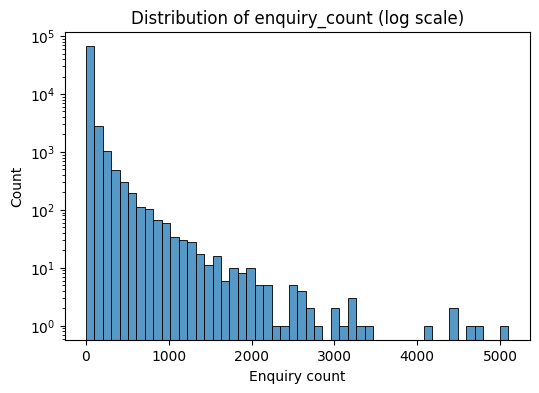

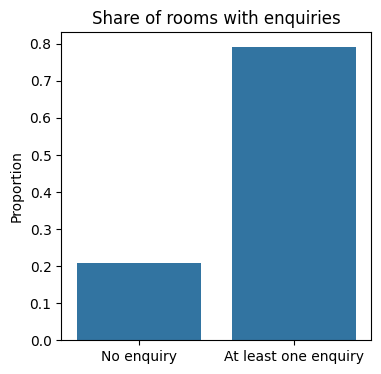

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Enquiry count distribution
plt.figure(figsize=(6,4))
sns.histplot(df[COL["enquiry_cnt"]], bins=50)
plt.yscale("log")
plt.title("Distribution of enquiry_count (log scale)")
plt.xlabel("Enquiry count")
plt.show()

# Binary target balance
plt.figure(figsize=(4,4))
sns.barplot(x=["No enquiry", "At least one enquiry"],
            y=[(df[COL["enquiry_cnt"]] == 0).mean(),
               (df[COL["enquiry_cnt"]] > 0).mean()])
plt.title("Share of rooms with enquiries")
plt.ylabel("Proportion")
plt.show()

Thesis takeaway (write this)

The engagement distribution is highly skewed, with a majority of rooms receiving no enquiries, supporting binary classification as the primary task.

## 4.6 Linguistic feature exploration

In [13]:
!pip -q install textstat

In [14]:
import re
import numpy as np
import pandas as pd

TEXT_COL = "text_clean"  # adjust if needed

# Use a sample for EDA if dataset is big (recommended)
df_eda = df.sample(5000, random_state=42).copy()
# df_eda = df.copy()

texts = df_eda[TEXT_COL].fillna("").astype(str).tolist()

rows = []
for doc in nlp.pipe(texts, batch_size=256, n_process=1):
    # tokens
    alpha_tokens = [t for t in doc if t.is_alpha]
    words = [t.text for t in alpha_tokens]
    word_count = len(words)

    # sentences
    sent_count = sum(1 for _ in doc.sents)
    sent_count = max(sent_count, 1)

    # POS ratios
    adjs = sum(1 for t in alpha_tokens if t.pos_ == "ADJ")
    nouns = sum(1 for t in alpha_tokens if t.pos_ in ("NOUN", "PROPN"))
    verbs = sum(1 for t in alpha_tokens if t.pos_ == "VERB")

    # punctuation density
    punct_count = sum(1 for t in doc if t.is_punct)

    # readability proxies (cheap + stable)
    avg_word_len = (sum(len(w) for w in words) / word_count) if word_count else np.nan
    long_word_ratio = (sum(1 for w in words if len(w) >= 7) / word_count) if word_count else np.nan
    avg_sent_len = (word_count / sent_count) if sent_count else np.nan

    rows.append({
        "rd_word_count": word_count,
        "rd_sentence_count": sent_count,
        "rd_avg_sentence_length": avg_sent_len,
        "rd_adj_ratio": (adjs / word_count) if word_count else np.nan,
        "rd_noun_ratio": (nouns / word_count) if word_count else np.nan,
        "rd_verb_ratio": (verbs / word_count) if word_count else np.nan,
        "rd_punct_per_word": (punct_count / word_count) if word_count else np.nan,
        "rd_avg_word_length": avg_word_len,
        "rd_long_word_ratio": long_word_ratio,
    })

ling_feats = pd.DataFrame(rows, index=df_eda.index)
df_eda = pd.concat([df_eda, ling_feats], axis=1)

df_eda[[
    "rd_word_count","rd_sentence_count","rd_avg_sentence_length",
    "rd_adj_ratio","rd_noun_ratio","rd_verb_ratio",
    "rd_punct_per_word","rd_avg_word_length","rd_long_word_ratio"
]].describe()

,rd_word_count,rd_sentence_count,rd_avg_sentence_length,rd_adj_ratio,rd_noun_ratio,rd_verb_ratio,rd_punct_per_word,rd_avg_word_length,rd_long_word_ratio
count,"5,000.000","5,000.000","5,000.000","5,000.000","5,000.000","5,000.000","5,000.000","5,000.000","5,000.000"
mean,184.488,9.557,19.833,0.127,0.358,0.104,0.154,5.078,0.281
std,84.897,4.185,6.969,0.032,0.056,0.025,0.044,4.313,0.061
min,2.000,1.000,2.000,0.000,0.162,0.000,0.000,3.800,0.000
25%,124.000,7.000,16.625,0.105,0.322,0.088,0.124,4.784,0.239
50%,162.000,9.000,19.400,0.126,0.354,0.104,0.148,5.010,0.279
75%,222.000,11.000,22.429,0.147,0.390,0.120,0.176,5.250,0.321
max,627.000,38.000,352.000,0.284,1.000,0.214,0.500,309.000,1.000


In [15]:
tmp = df_eda.copy()
tmp["has_enquiry"] = (tmp[COL["enquiry_cnt"]] > 0).astype(int)

### Plot A — Word count vs enquiry probability

/var/folders/mq/00dtyxzn3t79l2f74tfpjv700000gn/T/ipykernel_24175/1298671988.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = plot_df.groupby("wc_bin").agg(


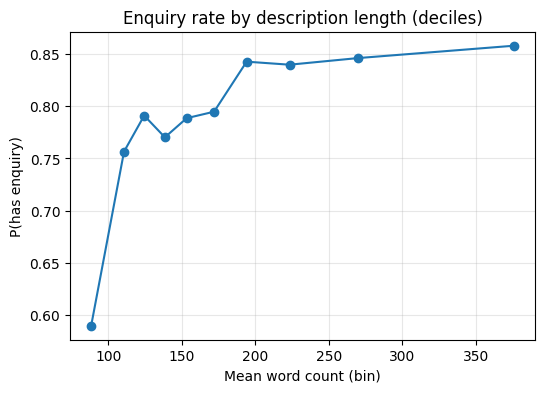

In [16]:
import matplotlib.pyplot as plt

plot_df = tmp[tmp["rd_word_count"] > 0].copy()
plot_df["wc_bin"] = pd.qcut(plot_df["rd_word_count"], q=10, duplicates="drop")

bin_stats = plot_df.groupby("wc_bin").agg(
    mean_word_count=("rd_word_count", "mean"),
    enquiry_rate=("has_enquiry", "mean"),
    n=("has_enquiry", "size")
).reset_index()

plt.figure(figsize=(6,4))
plt.plot(bin_stats["mean_word_count"], bin_stats["enquiry_rate"], marker="o")
plt.title("Enquiry rate by description length (deciles)")
plt.xlabel("Mean word count (bin)")
plt.ylabel("P(has enquiry)")
plt.grid(True, alpha=0.3)
plt.show()

Interpretation you will write:

Engagement probability increases with description length up to a point, indicating diminishing returns rather than monotonic improvement.

### Plot B — Readability vs engagement

/var/folders/mq/00dtyxzn3t79l2f74tfpjv700000gn/T/ipykernel_24175/1119603011.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = plot_df.groupby("lw_bin").agg(


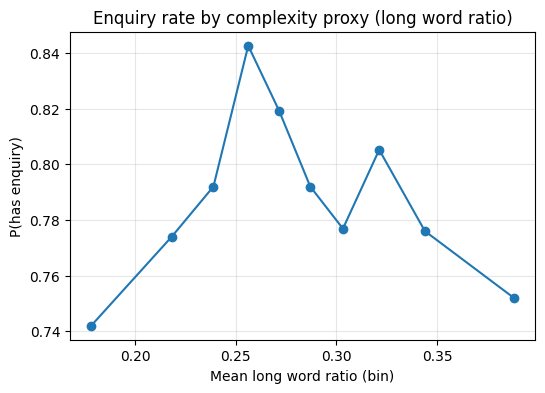

In [17]:
plot_df = tmp.dropna(subset=["rd_long_word_ratio"]).copy()
plot_df["lw_bin"] = pd.qcut(plot_df["rd_long_word_ratio"], q=10, duplicates="drop")

bin_stats = plot_df.groupby("lw_bin").agg(
    mean_long_word_ratio=("rd_long_word_ratio", "mean"),
    enquiry_rate=("has_enquiry", "mean"),
    n=("has_enquiry", "size")
).reset_index()

plt.figure(figsize=(6,4))
plt.plot(bin_stats["mean_long_word_ratio"], bin_stats["enquiry_rate"], marker="o")
plt.title("Enquiry rate by complexity proxy (long word ratio)")
plt.xlabel("Mean long word ratio (bin)")
plt.ylabel("P(has enquiry)")
plt.grid(True, alpha=0.3)
plt.show()

### Plot C — Adjective ratio vs engagement

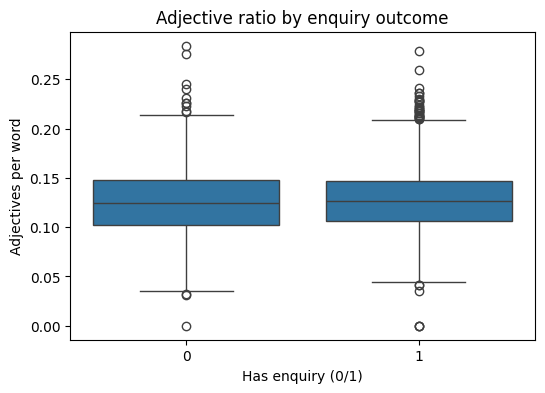

In [18]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="has_enquiry", y="rd_adj_ratio", data=tmp)
plt.title("Adjective ratio by enquiry outcome")
plt.xlabel("Has enquiry (0/1)")
plt.ylabel("Adjectives per word")
plt.show()

### Plot D — Correlation heatmap of linguistic features

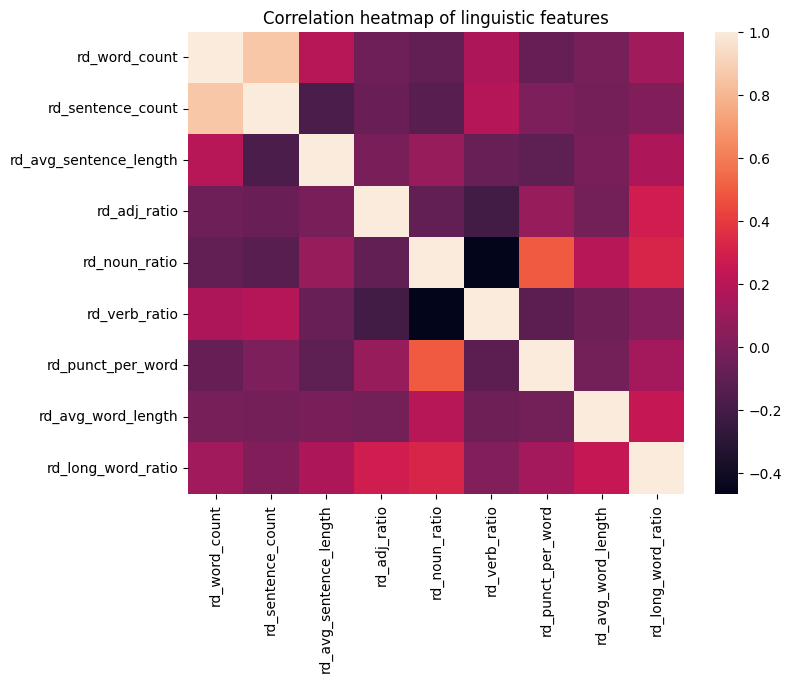

In [19]:
feat_cols = [
    "rd_word_count","rd_sentence_count","rd_avg_sentence_length",
    "rd_adj_ratio","rd_noun_ratio","rd_verb_ratio",
    "rd_punct_per_word","rd_avg_word_length","rd_long_word_ratio"
]

corr = tmp[feat_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False)
plt.title("Correlation heatmap of linguistic features")
plt.show()

This section extracts interpretable linguistic features (length, structure, POS ratios, and complexity proxies) from room descriptions. Preliminary visual analysis suggests non-linear relationships between text characteristics and enquiry outcomes, motivating inclusion of these features alongside TF-IDF and structured controls in subsequent modeling.

## 4.7 EDA summary and feature selection rationale

Exploratory analysis indicates that:
- Engagement outcomes are highly zero-inflated
- Text length, readability, and descriptive richness show non-linear relationships with enquiry probability
- Structural attributes explain a substantial portion of variance, but text alone contains meaningful signal

These findings motivate a modeling strategy that:
1. Uses binary enquiry occurrence as the primary target
2. Combines interpretable linguistic features with structural controls
3. Compares baseline, text-only, and combined models

4.7 EDA Summary and Modeling Implications

You can paste this directly as markdown in your notebook.

4.7 EDA Summary and Modeling Implications

Exploratory analysis provides several important insights that directly inform the modeling strategy.

1. Engagement Distribution

The distribution of enquiry counts is highly skewed and zero-inflated, with a substantial proportion of rooms receiving no enquiries. This justifies:

Using a binary target variable (has_enquiry) as the primary modeling task.

Using a log-transformed enquiry count as a secondary regression target.

This two-level strategy allows both classification and intensity modeling.

2. Text Length Effects

Binned analysis of word count suggests that engagement probability varies with description length and exhibits non-linear behavior. Extremely short descriptions underperform, while longer descriptions show diminishing returns.

Implication:

Include rd_word_count and rd_avg_sentence_length.

Consider non-linear models (tree-based models) or interaction terms.

3. Readability and Complexity

Complexity proxies such as long word ratio and average word length show variation across engagement groups. This suggests that lexical complexity may influence user response.

Implication:

Include readability/complexity features in modeling.

Compare their contribution against TF-IDF features.

4. Descriptive Style (POS Ratios)

Adjective density differs between rooms with and without enquiries, indicating that descriptive richness may relate to engagement.

Implication:

Include rd_adj_ratio, rd_noun_ratio, and rd_verb_ratio as interpretable linguistic predictors.

Use SHAP values to evaluate their contribution.

5. Feature Correlation Structure

Correlation analysis reveals moderate relationships among structural features (e.g., word count and sentence count). This motivates:

Regularization in linear models.

Inclusion of tree-based models robust to multicollinearity.

Final Modeling Strategy (Derived from EDA)

Based on the exploratory findings, the modeling framework will:

Use has_enquiry as the primary target.

Compare:

Baseline model (structured controls only)

Linguistic features only

TF-IDF features only

Combined model

Evaluate performance using ROC-AUC (classification) and R² / RMSE (regression).

Use SHAP values for interpretability and feature attribution.

Why this section matters

Now your thesis has:

EDA → Evidence → Justified modeling decisions

This moves it from:

“I ran ML on text”

to:

“Modeling choices were theoretically and empirically motivated.”

That’s a big difference academically.

# 5. Feature Engineering / Structured Feature Preparation

## 5.0 Helpers + canonical column names

In [20]:
import ast
import re
import numpy as np
import pandas as pd

# ---- Column names (works with or without COL mapping) ----
def col(name, default):
    return COL[name] if "COL" in globals() and name in COL else default

VENUE_TYPES_COL = col("venue_types", "venue_types")
PRICING_METHODS_COL = col("pricing_methods", "pricing_methods")
ENQUIRY_COL = col("enquiry_cnt", "enquiry_count")
CREATED_AT_COL = col("room_created_at", "room_created_at")

ROOM_DESC_COL = col("room_desc", "room_description")
VENUE_DESC_COL = col("venue_desc", "venue_description")

# ---- Reset previously engineered columns (so notebook reruns won't break) ----
prefixes_to_drop = ("venue_type__", "pricing_method__", "rd_")
explicit_drop = {
    "text_raw", "text_clean", "room_age_days",
    VENUE_TYPES_COL + "_list", PRICING_METHODS_COL + "_list"
}

cols_to_drop = [c for c in df.columns if c.startswith(prefixes_to_drop) or c in explicit_drop]
df = df.drop(columns=cols_to_drop, errors="ignore")

print("Dropped engineered columns:", len(cols_to_drop))

Dropped engineered columns: 1


### 5.1 Parse list-like columns (venue_types, pricing_methods)

These fields are stored as stringified lists. We parse them for EDA (and optional modeling later).


In [21]:
def parse_list_safe(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(i).strip() for i in x if str(i).strip()]

    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(i).strip().strip('"').strip("'") for i in parsed if str(i).strip()]
            return [str(parsed).strip().strip('"').strip("'")]
        except Exception:
            inner = s[1:-1].strip()
            return [inner] if inner else []

    return [s.strip().strip('"').strip("'")]

for c in [VENUE_TYPES_COL, PRICING_METHODS_COL]:
    if c in df.columns:
        df[c + "_list"] = df[c].apply(parse_list_safe)

# sanity counts
if VENUE_TYPES_COL + "_list" in df.columns:
    print("Unique venue_types:", df.explode(VENUE_TYPES_COL + "_list")[VENUE_TYPES_COL + "_list"].nunique())
if PRICING_METHODS_COL + "_list" in df.columns:
    print("Unique pricing_methods:", df.explode(PRICING_METHODS_COL + "_list")[PRICING_METHODS_COL + "_list"].nunique())

Unique venue_types: 37
Unique pricing_methods: 62


### 5.2 Multi-hot encoding

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

vt_list_col = VENUE_TYPES_COL + "_list"

mlb_vt = MultiLabelBinarizer()
vt_ohe = pd.DataFrame(
    mlb_vt.fit_transform(df[vt_list_col]) if vt_list_col in df.columns else np.zeros((len(df), 0)),
    columns=[f"venue_type__{c}" for c in (mlb_vt.classes_ if vt_list_col in df.columns else [])],
    index=df.index
)
df = pd.concat([df, vt_ohe], axis=1)

print("Venue type columns added:", vt_ohe.shape[1])

Venue type columns added: 37


### 5.3 Pricing methods: encode all if small else top-K + other

In [23]:
pm_list_col = PRICING_METHODS_COL + "_list"

pm_ohe = pd.DataFrame(index=df.index)

if pm_list_col in df.columns:
    pm_unique = df.explode(pm_list_col)[pm_list_col].nunique()

    if pm_unique <= 20:
        mlb_pm = MultiLabelBinarizer()
        pm_ohe = pd.DataFrame(
            mlb_pm.fit_transform(df[pm_list_col]),
            columns=[f"pricing_method__{c}" for c in mlb_pm.classes_],
            index=df.index
        )
        df = pd.concat([df, pm_ohe], axis=1)
        print("Pricing method columns encoded (all):", pm_ohe.shape[1])

    else:
        top_k = 15
        top_pm = (
            df.explode(pm_list_col)[pm_list_col]
            .value_counts()
            .head(top_k)
            .index
            .tolist()
        )
        for v in top_pm:
            df[f"pricing_method__{v}"] = df[pm_list_col].apply(lambda lst: int(v in lst))
        df["pricing_method__other"] = df[pm_list_col].apply(lambda lst: int(any(x not in set(top_pm) for x in lst)))

        pm_ohe = df[[f"pricing_method__{v}" for v in top_pm] + ["pricing_method__other"]]
        mlb_pm = None
        print(f"Pricing method columns encoded (top {top_k} + other):", pm_ohe.shape[1])

else:
    mlb_pm = None
    print("No pricing_methods list column found.")

Pricing method columns encoded (top 15 + other): 16


## Create room_age_days + assemble structured_features

In [24]:
# datetime + age (reproducible)
if CREATED_AT_COL in df.columns:
    df[CREATED_AT_COL] = pd.to_datetime(df[CREATED_AT_COL], errors="coerce", utc=True)
    reference_date = df[CREATED_AT_COL].max()
    df["room_age_days"] = (reference_date - df[CREATED_AT_COL]).dt.days
else:
    df["room_age_days"] = np.nan

# minimal, defensible controls
base_structured = [
    "room_min_price",
    "room_max_price",
    "min_attendees_per_event",
    "minimum_booking_hours",
    "selected_for_online_payments",
    "room_age_days",
    "city",
    "country",
    "pricing_type",
]

base_structured = [c for c in base_structured if c in df.columns]

structured_features = base_structured + list(vt_ohe.columns) + list(pm_ohe.columns)
print("Structured feature count:", len(structured_features))

Structured feature count: 62


5.2 Linguistic features (spaCy batched) → X_ling
5.2.1 Create text_raw and text_clean

Room description primary; venue description fallback.

In [25]:
def coalesce_text(room_text, venue_text):
    r = "" if pd.isna(room_text) else str(room_text)
    v = "" if pd.isna(venue_text) else str(venue_text)
    return r if r.strip() else v

df["text_raw"] = [
    coalesce_text(r, v)
    for r, v in zip(df.get(ROOM_DESC_COL, ""), df.get(VENUE_DESC_COL, ""))
]

def clean_text_basic(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df["text_raw"].fillna("").astype(str).map(clean_text_basic)
text_clean = df["text_clean"]

5.2.2 Linguistic feature extraction

In [26]:
import spacy

# Ensure model installed:
# !python -m spacy download en_core_web_sm

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

texts = text_clean.tolist()

rows = []
for doc in nlp.pipe(texts, batch_size=512, n_process=1):
    alpha_tokens = [t for t in doc if t.is_alpha]
    wc = len(alpha_tokens)

    sent_count = sum(1 for _ in doc.sents)
    sent_count = max(sent_count, 1)

    adjs = sum(1 for t in alpha_tokens if t.pos_ == "ADJ")
    nouns = sum(1 for t in alpha_tokens if t.pos_ in ("NOUN", "PROPN"))
    verbs = sum(1 for t in alpha_tokens if t.pos_ == "VERB")
    punct = sum(1 for t in doc if t.is_punct)

    words = [t.text for t in alpha_tokens]
    avg_word_len = (sum(len(w) for w in words) / wc) if wc else 0.0
    long_word_ratio = (sum(1 for w in words if len(w) >= 7) / wc) if wc else 0.0
    avg_sent_len = (wc / sent_count) if sent_count else 0.0

    rows.append({
        "rd_word_count": wc,
        "rd_sentence_count": sent_count,
        "rd_avg_sentence_length": avg_sent_len,
        "rd_adj_ratio": adjs / wc if wc else 0.0,
        "rd_noun_ratio": nouns / wc if wc else 0.0,
        "rd_verb_ratio": verbs / wc if wc else 0.0,
        "rd_punct_per_word": punct / wc if wc else 0.0,
        "rd_avg_word_length": avg_word_len,
        "rd_long_word_ratio": long_word_ratio,
    })

ling_feats = pd.DataFrame(rows, index=df.index)
df = pd.concat([df, ling_feats], axis=1)

linguistic_features = list(ling_feats.columns)
X_ling = df[linguistic_features].copy()

print("Linguistic feature count:", len(linguistic_features))

Linguistic feature count: 9


5.3 Text representations (plug-in design)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer

def build_text_vectorizer(kind="tfidf_word"):
    if kind == "tfidf_word":
        return TfidfVectorizer(
            max_features=8000,
            min_df=5,
            ngram_range=(1,2),
            stop_words="english"
        )
    if kind == "tfidf_char":
        return TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3,5),
            min_df=5,
            max_features=12000
        )
    if kind == "hashing":
        return HashingVectorizer(
            n_features=2**18,
            alternate_sign=False,
            norm="l2",
            ngram_range=(1,2),
            stop_words="english"
        )
    raise ValueError(f"Unknown kind: {kind}")

def build_text_matrices(train_text, test_text, kind="tfidf_word"):
    vec = build_text_vectorizer(kind)
    if kind == "hashing":
        X_train = vec.transform(train_text)
        X_test = vec.transform(test_text)
        return X_train, X_test, vec
    X_train = vec.fit_transform(train_text)
    X_test = vec.transform(test_text)
    return X_train, X_test, vec

# Optional: MiniLM embeddings hook (off by default)
USE_MINILM = False

def build_minilm_embeddings(train_text, test_text, pca_components=50):
    from sentence_transformers import SentenceTransformer
    from sklearn.decomposition import PCA

    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    E_train = embedder.encode(list(train_text), show_progress_bar=True)
    E_test  = embedder.encode(list(test_text), show_progress_bar=True)

    if pca_components:
        pca = PCA(n_components=pca_components, random_state=42)
        E_train = pca.fit_transform(E_train)
        E_test  = pca.transform(E_test)
        meta = {"embedder": "all-MiniLM-L6-v2", "pca_components": pca_components}
        return E_train, E_test, meta

    meta = {"embedder": "all-MiniLM-L6-v2", "pca_components": None}
    return E_train, E_test, meta

Outputs (frozen modeling inputs)

In [28]:
X_struct = df[structured_features].copy()
text_clean = df["text_clean"].copy()

print("X_struct:", X_struct.shape)
print("X_ling:", X_ling.shape)
print("text_clean:", text_clean.shape)

X_struct: (73448, 62)
X_ling: (73448, 9)
text_clean: (73448,)


In [29]:
assert df.columns.is_unique, "Duplicate columns exist — rerun-safe reset failed."

## 6. Train/Test Split (Grouped) + Modeling Inputs


6.1 Targets (binary + optional regression)

In [30]:
from sklearn.model_selection import GroupShuffleSplit

# Primary target
df["has_enquiry"] = (df[ENQUIRY_COL] > 0).astype(int)

y = df["has_enquiry"]

# Optional secondary target (if you want later)
df["log_enquiry_count"] = np.log1p(df[ENQUIRY_COL].fillna(0))


6.2 Grouped split (IMPORTANT: prevents leakage)

In [31]:
GROUP_COL = "venue_id"  # adjust if needed
TEST_SIZE = 0.2
RANDOM_STATE = 42

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)

train_idx, test_idx = next(
    gss.split(df, y, groups=df[GROUP_COL])
)

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print("Train rows:", df_train.shape[0], " Test rows:", df_test.shape[0])
print("Unique venues train:", df_train[GROUP_COL].nunique(), " test:", df_test[GROUP_COL].nunique())


Train rows: 58555  Test rows: 14893
Unique venues train: 21705  test: 5427


In [32]:
overlap = set(df_train[GROUP_COL]).intersection(set(df_test[GROUP_COL]))
print("Venue overlap:", len(overlap))

Venue overlap: 0


6.3 Prepare modeling inputs (no fitting here)

In [33]:
# Structured block (raw)
X_struct_train = df_train[structured_features].copy()
X_struct_test  = df_test[structured_features].copy()

print("X_struct_train:", X_struct_train.shape, "X_struct_test:", X_struct_test.shape)

X_struct_train: (58555, 62) X_struct_test: (14893, 62)


In [34]:
# Linguistic block (numeric, already engineered)
X_ling_train = df_train[linguistic_features].copy().fillna(0)
X_ling_test  = df_test[linguistic_features].copy().fillna(0)

print("X_ling_train:", X_ling_train.shape, "X_ling_test:", X_ling_test.shape)


X_ling_train: (58555, 9) X_ling_test: (14893, 9)


In [35]:
# Text block (for TF-IDF / hashing / embeddings)
train_text = df_train["text_clean"].fillna("").astype(str).tolist()
test_text  = df_test["text_clean"].fillna("").astype(str).tolist()

print("Text samples:", train_text[0][:80], "...")

Text samples: charlie’s by the charlie borrow workshop. a fully licensed bar and private hire  ...


6.4 Optional: store indices for reproducibility

In [36]:
train_text = df_train["text_clean"].fillna("").astype(str).tolist()
test_text  = df_test["text_clean"].fillna("").astype(str).tolist()

print("Text samples:", train_text[0][:80], "...")

Text samples: charlie’s by the charlie borrow workshop. a fully licensed bar and private hire  ...


6.5 What this enables (next Part 7)

Now you can build the exact A/B/C framework consistently:

Model A: structured only (with proper encoding for categoricals)

Model B: text only (TF-IDF / hashing / embeddings)

Model C: combined (structured + text + optional linguistic)

## 7. Modeling: A / B / C Comparison Framework
7.0 Imports

In [37]:
from scipy.sparse import hstack, csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

### 7.1 Define structured feature types

We need to separate:
- numeric structured
- categorical structured
- already multi-hot columns (venue_type__, pricing_method__) can be treated as numeric/binary

In [38]:
numeric_structured = [
    c for c in structured_features
    if c in X_struct_train.columns
    and c not in ["city", "country", "pricing_type"]
    and not X_struct_train[c].dtype == "object"
]

categorical_structured = [
    c for c in ["city", "country", "pricing_type"]
    if c in X_struct_train.columns
]

# binary / multi-hot columns are already numeric and included in numeric_structured if dtype is numeric
# if some binary columns are object by accident, force them numeric:
for c in X_struct_train.columns:
    if c.startswith("venue_type__") or c.startswith("pricing_method__"):
        X_struct_train[c] = pd.to_numeric(X_struct_train[c], errors="coerce")
        X_struct_test[c] = pd.to_numeric(X_struct_test[c], errors="coerce")

numeric_structured = [
    c for c in structured_features
    if c in X_struct_train.columns and c not in categorical_structured
]

print("Numeric structured:", len(numeric_structured))
print("Categorical structured:", categorical_structured)

Numeric structured: 59
Categorical structured: ['city', 'country', 'pricing_type']


## 7.2 Build structured preprocessor

This handles:
- numeric imputation
- scaling
- categorical one-hot encoding

In [39]:
structured_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
                ("scaler", StandardScaler())
            ]),
            numeric_structured
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_structured
        )
    ],
    remainder="drop"
)

In [40]:
X_struct_train_proc = structured_preprocessor.fit_transform(X_struct_train)
X_struct_test_proc = structured_preprocessor.transform(X_struct_test)

print("Processed structured train:", X_struct_train_proc.shape)
print("Processed structured test :", X_struct_test_proc.shape)

Processed structured train: (58555, 2012)
Processed structured test : (14893, 2012)


### 7.3 Optional linguistic block scaling

In [41]:
ling_scaler = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

X_ling_train_proc = ling_scaler.fit_transform(X_ling_train)
X_ling_test_proc = ling_scaler.transform(X_ling_test)

print("Processed linguistic train:", X_ling_train_proc.shape)
print("Processed linguistic test :", X_ling_test_proc.shape)

Processed linguistic train: (58555, 9)
Processed linguistic test : (14893, 9)


### 7.4 Generic evaluation helper

In [42]:
def evaluate_binary_model(model, X_train, X_test, y_train, y_test, model_name, representation, include_ling=False):
    model.fit(X_train, y_train)
    pred_proba = model.predict_proba(X_test)[:, 1]
    pred_label = (pred_proba >= 0.5).astype(int)

    return {
        "representation": representation,
        "model": model_name,
        "include_ling": include_ling,
        "roc_auc": roc_auc_score(y_test, pred_proba),
        "accuracy": accuracy_score(y_test, pred_label)
    }

### 7.5 Model A — Structured only
This is your baseline.

In [43]:
model_A = LogisticRegression(max_iter=1000, random_state=42)

result_A = evaluate_binary_model(
    model=model_A,
    X_train=X_struct_train_proc,
    X_test=X_struct_test_proc,
    y_train=y_train,
    y_test=y_test,
    model_name="A_structured",
    representation="structured_only",
    include_ling=False
)

result_A

{'representation': 'structured_only',
 'model': 'A_structured',
 'include_ling': False,
 'roc_auc': 0.7195038764494421,
 'accuracy': 0.7876854898274357}

### 7.6 Model B + C loop for text representations

This evaluates:
- B_text = text only
- C_combined = structured + text
- optional C_combined_plus_ling = structured + text + linguistic

In [44]:
results = [result_A]

text_representations = ["tfidf_word", "tfidf_char", "hashing"]

for kind in text_representations:
    print(f"Running representation: {kind}")

    # Build text matrices
    X_text_train, X_text_test, vec = build_text_matrices(train_text, test_text, kind=kind)

    # --- Model B: text only ---
    model_B = LogisticRegression(max_iter=1000, random_state=42)

    res_B = evaluate_binary_model(
        model=model_B,
        X_train=X_text_train,
        X_test=X_text_test,
        y_train=y_train,
        y_test=y_test,
        model_name="B_text_only",
        representation=kind,
        include_ling=False
    )
    results.append(res_B)

    # --- Model C: structured + text ---
    X_comb_train = hstack([X_struct_train_proc, X_text_train])
    X_comb_test = hstack([X_struct_test_proc, X_text_test])

    model_C = LogisticRegression(max_iter=1000, random_state=42)

    res_C = evaluate_binary_model(
        model=model_C,
        X_train=X_comb_train,
        X_test=X_comb_test,
        y_train=y_train,
        y_test=y_test,
        model_name="C_combined",
        representation=kind,
        include_ling=False
    )
    results.append(res_C)

    # --- Optional: structured + text + linguistic ---
    X_comb_ling_train = hstack([X_struct_train_proc, csr_matrix(X_ling_train_proc), X_text_train])
    X_comb_ling_test = hstack([X_struct_test_proc, csr_matrix(X_ling_test_proc), X_text_test])

    model_C_ling = LogisticRegression(max_iter=1000, random_state=42)

    res_C_ling = evaluate_binary_model(
        model=model_C_ling,
        X_train=X_comb_ling_train,
        X_test=X_comb_ling_test,
        y_train=y_train,
        y_test=y_test,
        model_name="C_combined_plus_ling",
        representation=kind,
        include_ling=True
    )
    results.append(res_C_ling)

Running representation: tfidf_word
Running representation: tfidf_char
Running representation: hashing


### 7.7 Results table

In [45]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["roc_auc", "accuracy"], ascending=False).reset_index(drop=True)

results_df

,representation,model,include_ling,roc_auc,accuracy
0,hashing,C_combined_plus_ling,True,0.755,0.793
1,hashing,C_combined,False,0.754,0.793
2,tfidf_char,C_combined,False,0.750,0.788
3,tfidf_char,C_combined_plus_ling,True,0.750,0.788
4,tfidf_word,C_combined_plus_ling,True,0.748,0.788
5,tfidf_word,C_combined,False,0.747,0.789
6,structured_only,A_structured,False,0.720,0.788
7,hashing,B_text_only,False,0.693,0.785
8,tfidf_char,B_text_only,False,0.688,0.784
9,tfidf_word,B_text_only,False,0.682,0.780


### 7.8 Add incremental lift vs structured baseline

This is one of the most important outputs in your thesis.

In [46]:
baseline_auc = results_df.loc[results_df["model"] == "A_structured", "roc_auc"].iloc[0]

results_df["lift_vs_structured"] = results_df["roc_auc"] - baseline_auc

results_df.sort_values("roc_auc", ascending=False)

,representation,model,include_ling,roc_auc,accuracy,lift_vs_structured
0,hashing,C_combined_plus_ling,True,0.755,0.793,0.036
1,hashing,C_combined,False,0.754,0.793,0.035
2,tfidf_char,C_combined,False,0.750,0.788,0.030
3,tfidf_char,C_combined_plus_ling,True,0.750,0.788,0.030
4,tfidf_word,C_combined_plus_ling,True,0.748,0.788,0.028
5,tfidf_word,C_combined,False,0.747,0.789,0.027
6,structured_only,A_structured,False,0.720,0.788,0.000
7,hashing,B_text_only,False,0.693,0.785,-0.026
8,tfidf_char,B_text_only,False,0.688,0.784,-0.032
9,tfidf_word,B_text_only,False,0.682,0.780,-0.038



### 7.10 Simple chart

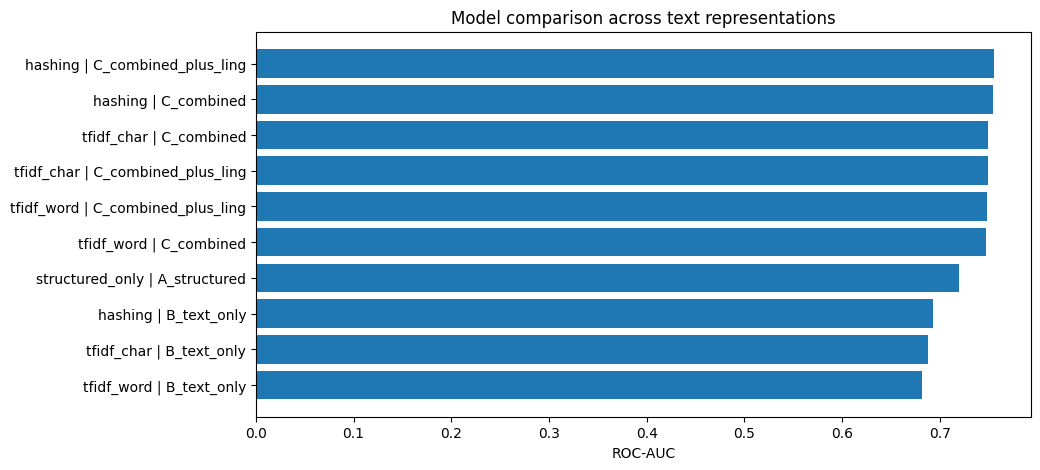

In [47]:
import matplotlib.pyplot as plt

plot_df = results_df.copy()
plot_df["label"] = plot_df["representation"] + " | " + plot_df["model"]

plt.figure(figsize=(10,5))
plt.barh(plot_df["label"], plot_df["roc_auc"])
plt.xlabel("ROC-AUC")
plt.title("Model comparison across text representations")
plt.gca().invert_yaxis()
plt.show()

### 8.1 Top Words Driving Enquiries (TF-IDF)

In [48]:
model = model_C  # your best combined model

# NOTE: for sparse + combined, feature names are not trivial
# so interpret structured part separately

Extract structured coefficients only

In [49]:
struct_feature_names = structured_preprocessor.get_feature_names_out()

coef_struct = model.coef_[0][:len(struct_feature_names)]

struct_df = pd.DataFrame({
    "feature": struct_feature_names,
    "coef": coef_struct
}).sort_values("coef", ascending=False)

struct_df.head(15)

,feature,coef
568,cat__city_Dublin 2,1.981
122,cat__city_Aventura,1.786
1947,cat__city_Wolverhampton,1.685
1691,cat__city_Stockport,1.651
437,cat__city_Coburg North,1.640
1762,cat__city_The Bronx,1.610
249,cat__city_Bradford,1.564
1443,cat__city_Prahran,1.553
1481,cat__city_Reservoir,1.524
1378,cat__city_Parramatta,1.465


### 8.3 Linguistic Feature Interpretation

Fit model on linguistic features only

In [50]:
model_ling = LogisticRegression(max_iter=1000)
model_ling.fit(X_ling_train_proc, y_train)

coef_ling = pd.DataFrame({
    "feature": linguistic_features,
    "coef": model_ling.coef_[0]
}).sort_values("coef", ascending=False)

coef_ling

,feature,coef
0,rd_word_count,0.307
2,rd_avg_sentence_length,0.121
8,rd_long_word_ratio,0.067
1,rd_sentence_count,0.049
4,rd_noun_ratio,0.003
7,rd_avg_word_length,-0.007
5,rd_verb_ratio,-0.041
3,rd_adj_ratio,-0.045
6,rd_punct_per_word,-0.088


### 8.4 (Optional but Strong) SHAP with XGBoost

If you want to go from good → excellent thesis

Train XGBoost (combined)

In [51]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model_xgb.fit(X_comb_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

SHAP values

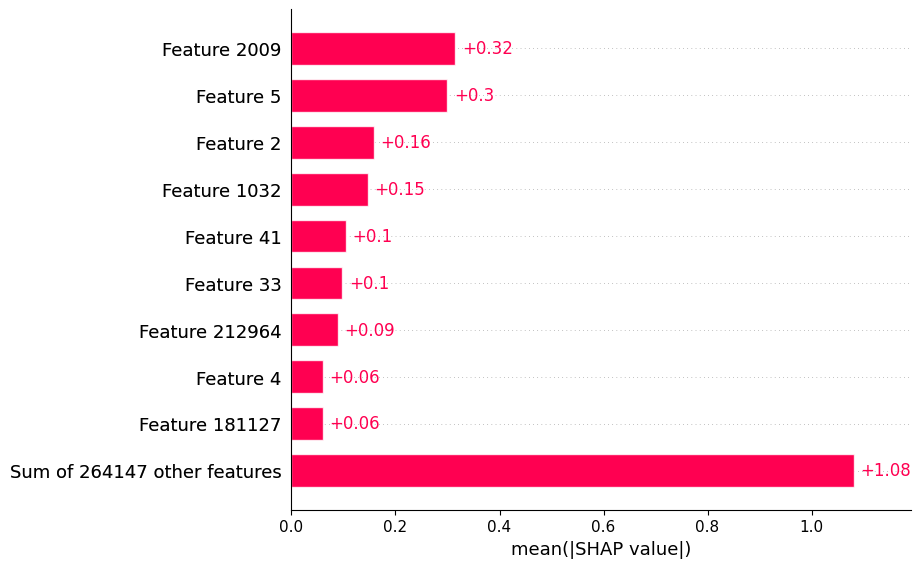

In [53]:
import shap

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_comb_test[:1000])  # sample for speed

shap.plots.bar(shap_values)